<a href="https://colab.research.google.com/github/mokshManchandani/data-science/blob/deeplearning-pytorch-udemy/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ANN For regression

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')

<ipython-input-1-2ce0d24443bf>:6: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


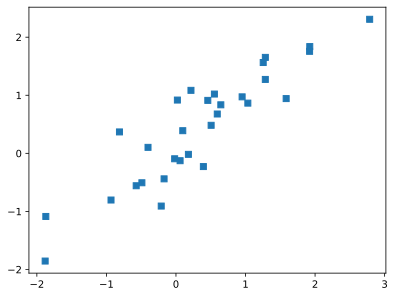

In [2]:
# Create Data
N = 30
x = torch.randn(N,1)
y = x + torch.randn(N,1) / 2


plt.plot(x,y,'s');

In [3]:
# build model
ANNReg = nn.Sequential(
  nn.Linear(1, 1),
  nn.ReLU(),
  nn.Linear(1,1)
)

ANNReg

Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1, out_features=1, bias=True)
)

In [4]:
# learning rate
learning_rate = 0.05

# loss function

lossfunc = nn.MSELoss()

# optimizer
optimizer = torch.optim.SGD(ANNReg.parameters(), lr=learning_rate)

In [5]:
# training loop
numepochs = 500
lossi = torch.zeros(numepochs)

for epochi in range(numepochs):
  yHat = ANNReg(x)
  loss = lossfunc(yHat, y)
  lossi[epochi] = loss

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()


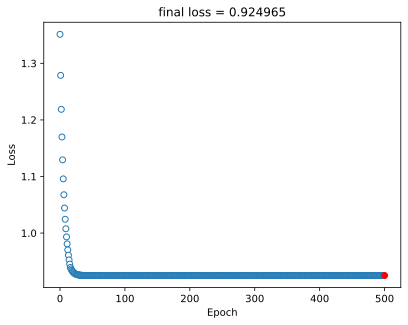

In [6]:
predictions = ANNReg(x)
testloss = (predictions - y).pow(2).mean()

plt.plot(lossi.detach().numpy(),'o', markerfacecolor='w', linewidth=.1)
plt.plot(numepochs, testloss.detach().numpy(),'ro')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('final loss = %g'%testloss.item())
plt.show();

/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


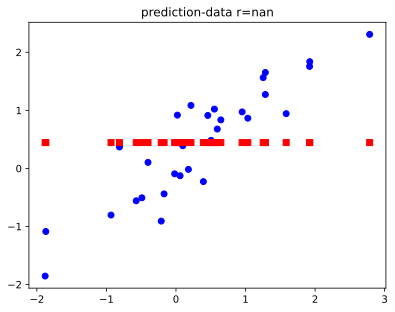

In [7]:
plt.plot(x, y, 'bo', label='real data')
plt.plot(x, predictions.detach(), 'rs', label='predictions')
plt.title(f'prediction-data r={np.corrcoef(y.T, predictions.detach().T)[0,1]:.2f}');

Code challenge for the above.

In [19]:
import numpy as np
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')

<ipython-input-19-2da2361c6caa>:6: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


In [20]:
def create_data(N, m=1):
  x = torch.randn(N,1)
  y = m * x + torch.randn(N,1) / 2
  # plt.plot(x,y,'s');
  return x, y

In [21]:
def build_and_train_model(x, y, num_epochs, learning_rate, loss_func, optimizer_func):
# package the code of building and training the model into a function
  # build the model
  model = nn.Sequential(
    nn.Linear(1, 1),
    nn.ReLU(),
    nn.Linear(1,1)
  )


  # init the optimizer
  optimizer = optimizer_func(model.parameters(), lr=learning_rate)
  # track the stats
  lossi = torch.zeros(num_epochs)


  # train the model
  for epochi in range(num_epochs):
    yHat = model(x)
    loss = loss_func(yHat, y)
    lossi[epochi]= loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


  predictions = model(x)
  # testloss = (predictions - y).pow(2).mean()

  # plt.figure(figsize=(10,4))
  # # show two plots on the same row
  # # show the loss over epochs
  # plt.subplot(1,2,1)
  # plt.plot(lossi.detach().numpy(),'o', markerfacecolor='w', linewidth=.1)
  # plt.xlabel('Epoch')
  # plt.ylabel('Loss')
  # plt.title('final loss = %g'%testloss.item())

  # # show the accuracy
  # plt.subplot(1,2,2)
  # plt.plot(x, y, 'bo', label='real data')
  # plt.plot(x, predictions.detach(), 'rs', label='predictions')
  # plt.title(f'prediction-data r={np.corrcoef(y.T, predictions.detach().T)[0,1]:.2f}');

  return lossi, predictions


In [22]:
# get the data
x, y = create_data(N = 50)

In [23]:
# train the model
lossi, predictions = build_and_train_model(x, y, num_epochs=500, learning_rate=0.05, loss_func = nn.MSELoss(), optimizer_func=torch.optim.SGD)

In [24]:
# create slopes from -2, +2 in 21 steps

slopes = torch.linspace(-2,2,21)
num_experiments = 50

results = np.zeros((len(slopes), num_experiments, 2))


for slopeidx, slope in enumerate(slopes):
  for experimenti in range(num_experiments):
    x, y = create_data(N = 50, m = slope)
    lossi, yHat = build_and_train_model(x, y, num_epochs=500, learning_rate=0.05, loss_func = nn.MSELoss(), optimizer_func=torch.optim.SGD)
    results[slopeidx, experimenti, 0] = lossi[-1].item()
    results[slopeidx, experimenti, 1] = np.corrcoef(y.T, yHat.detach().T)[0,1]

results.shape


/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


(21, 50, 2)

In [25]:
# reset nan-> 0
results[np.isnan(results)] = 0

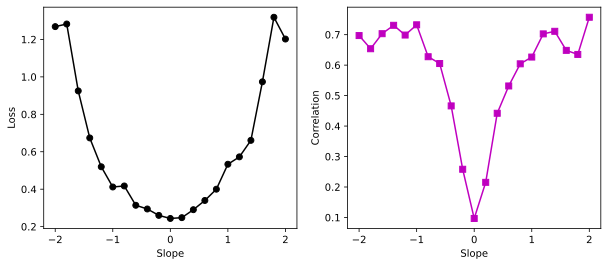

In [26]:
fix, ax = plt.subplots(1,2, figsize=(10,4))

ax[0].plot(slopes, results[:,:,0].mean(axis=1), 'ko-')
ax[0].set_xlabel('Slope')
ax[0].set_ylabel('Loss')

ax[1].plot(slopes, results[:,:,1].mean(axis=1), 'ms-')
ax[1].set_xlabel('Slope')
ax[1].set_ylabel('Correlation')

plt.show()

## ANN For classification - binary classification

In [17]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')

<ipython-input-17-2ce0d24443bf>:6: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


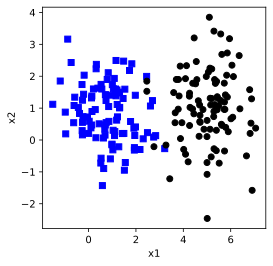

In [18]:
nPerCluster = 100
blur = 1
A = [1, 1]
B = [5, 1]

a = [ A[0] + np.random.randn(nPerCluster) * blur, A[1] + np.random.randn(nPerCluster) * blur]
b =  [ B[0] + np.random.randn(nPerCluster) * blur, B[1] + np.random.randn(nPerCluster) * blur]


# true labels
labels = np.vstack((np.zeros((nPerCluster,1)), np.ones((nPerCluster,1))))

data_points = np.hstack((a,b)).T

data = torch.tensor(data_points).float()
labels = torch.tensor(labels).float()

fig = plt.figure(figsize=(4,4))

plt.plot(data[np.where(labels == 0)[0],0], data[np.where(labels == 0)[0], 1],'bs')
plt.plot(data[np.where(labels == 1)[0],0], data[np.where(labels == 1)[0], 1],'ko')
plt.xlabel('x1')
plt.ylabel('x2')

plt.show()

In [19]:
ANNClassify = nn.Sequential(
  nn.Linear(2, 1),
  nn.ReLU(),
  nn.Linear(1, 1),
  nn.Sigmoid()
)
ANNClassify

Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1, out_features=1, bias=True)
  (3): Sigmoid()
)

In [20]:
learning_rate = .01
lossf = nn.BCELoss()
optimizer = torch.optim.SGD(ANNClassify.parameters(), lr=learning_rate)

In [21]:
numepochs = 1000
lossi = torch.zeros(numepochs)

for epochi in range(numepochs):
  yHat = ANNClassify(data)
  loss = lossf(yHat, labels)
  lossi[epochi] = loss
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

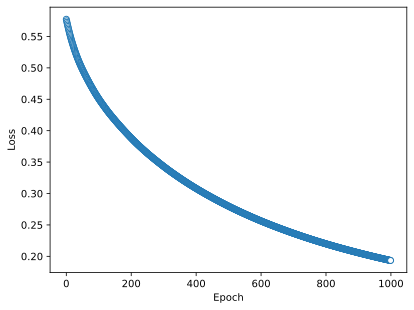

In [22]:
plt.plot(lossi.detach().numpy(),'o', markerfacecolor='w', linewidth=.1)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show();

In [23]:
predictions = ANNClassify(data)
predlabels = predictions > .5



misclassified = np.where(predlabels != labels)[0]
print(np.where(predlabels != labels))

totalacc = 100 - 100 * len(misclassified) / len(labels)
print(f'total accuracy = {totalacc}%')

(array([15, 51, 62, 74, 86, 92, 96]), array([0, 0, 0, 0, 0, 0, 0]))
total accuracy = 96.5%


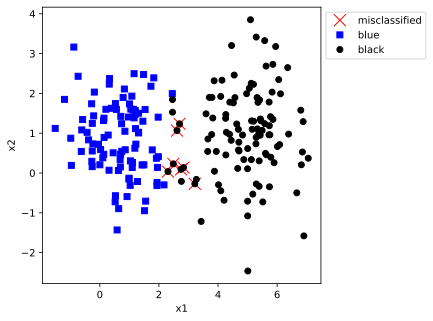

In [24]:
fig = plt.figure(figsize=(5,5))
plt.plot(data[misclassified, 0], data[misclassified, 1], 'rx', markersize=12)
plt.plot(data[np.where(~predlabels)[0], 0], data[np.where(~predlabels)[0], 1], 'bs')
plt.plot(data[np.where(predlabels)[0], 0], data[np.where(predlabels)[0], 1], 'ko')
plt.legend(['misclassified', 'blue', 'black'], bbox_to_anchor=(1,1))
plt.xlabel('x1')
plt.ylabel('x2');

The appropriate learning rate experiment

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')

<ipython-input-1-2ce0d24443bf>:6: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


In [2]:
# create the data
n_per_cluster = 100
blur = 1

A = [ 1, 1 ]
B = [ 5, 1 ]

a = [ A[0]+np.random.randn(n_per_cluster)*blur, A[1]+np.random.randn(n_per_cluster)*blur ]
b = [ B[0]+np.random.randn(n_per_cluster)*blur, B[1]+np.random.randn(n_per_cluster)*blur ]

# class 0, class 1.
# class 0 -> blue
# class 1 -> black
labels = np.vstack((np.zeros((n_per_cluster,1)), np.ones((n_per_cluster,1))))

# create the x1x2 coordinates for the labels above.
data_points = np.hstack((a, b)).T

# convert to torch tensors
data = torch.from_numpy(data_points).float()
labels = torch.from_numpy(labels).float()

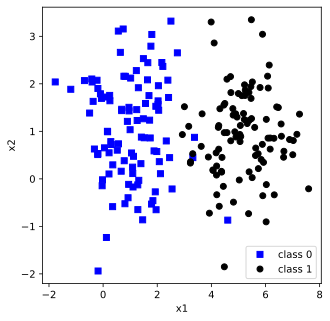

In [3]:
# display the data landscape
fig = plt.figure(figsize=(5, 5))
plt.plot(data[np.where(labels == 0)[0],0], data[np.where(labels==0)[0], 1], 'bs',label="class 0")
plt.plot(data[np.where(labels == 1)[0],0], data[np.where(labels==1)[0], 1], 'ko', label="class 1")
plt.legend()
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [15]:
def createANNModel(learning_rate):
  model = nn.Sequential(
    nn.Linear(2, 1),
    nn.ReLU(),
    nn.Linear(1, 1)
  )

  loss_func = nn.BCEWithLogitsLoss()
  optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
  return model, loss_func, optimizer

In [16]:
def train_model(x, y, model, loss_func, optimizer, num_epochs):
  losses = torch.zeros(num_epochs)

  # train and track
  for epoch in range(num_epochs):
    yhat = model(x)
    loss = loss_func(yhat, y)
    losses[epoch] = loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  # final predictions after training the model
  predictions = model(x)

  # accuracy of the model
  totalacc = 100 * torch.mean(((predictions > 0) == y).float())
  return losses, predictions, totalacc



In [25]:
model, loss_func, optimizer = createANNModel(learning_rate=0.01)

In [26]:
losses, predictions, totalacc = train_model(data, labels, model, loss_func, optimizer, 2000)

final accuracy: 98.00


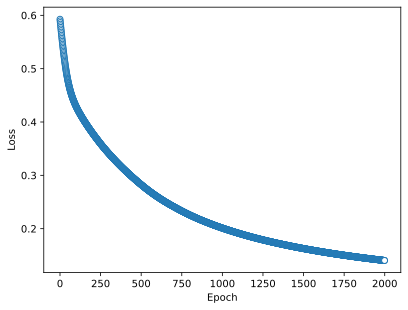

In [27]:
print(f"final accuracy: {totalacc:.2f}")
plt.plot(losses.detach(), 'o', markerfacecolor='w', linewidth=.1)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [36]:
num_epochs = 1000
learning_rates = np.linspace(.001, .1, 40)
accByLr = []
allLosses = np.zeros((len(learning_rates), num_epochs))

for i, lr in enumerate(learning_rates):
  model, loss_func, optimizer = createANNModel(learning_rate = lr)
  losses, predictions, totalacc = train_model(
    x = data,
    y = labels,
    model = model,
    loss_func = loss_func,
    optimizer = optimizer,
    num_epochs = num_epochs
  )
  accByLr.append(totalacc.item())
  allLosses[i, :] = losses.detach().numpy()

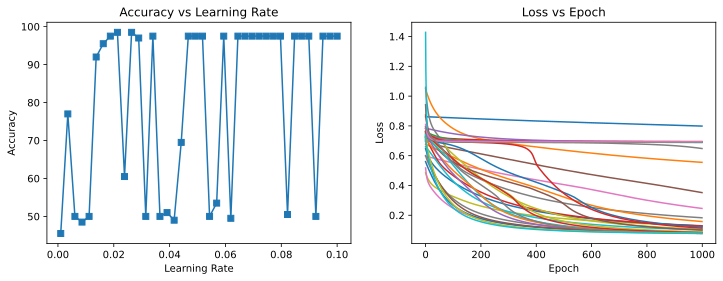

In [37]:
# plot the results
fig, ax = plt.subplots(1,2,figsize=(12, 4))

ax[0].plot(learning_rates, accByLr, 's-')
ax[0].set_xlabel('Learning Rate')
ax[0].set_ylabel('Accuracy')
# ax[0].set_xscale('log')
ax[0].set_title('Accuracy vs Learning Rate')

ax[1].plot(allLosses.T)
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].set_title('Loss vs Epoch')

plt.show()

In [39]:
# to take into account the variablity due to randomness we need to run the same experiment for n number of times

num_experiments = 50
results = np.zeros((num_experiments, len(learning_rates)))
num_epochs = 500

for expi in range(num_experiments):
  for i, lr in enumerate(learning_rates):
    model, loss_func, optimizer = createANNModel(learning_rate = lr)
    losses, predictions, totalacc = train_model(
      x = data,
      y = labels,
      model = model,
      loss_func = loss_func,
      optimizer = optimizer,
      num_epochs = num_epochs
    )
    results[expi, i] = totalacc.item()


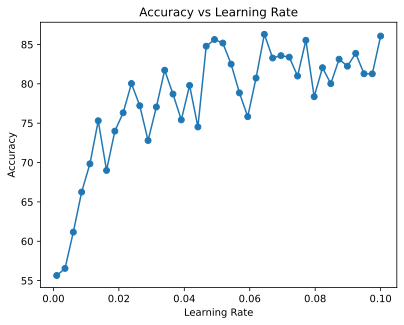

In [40]:
plt.plot(learning_rates, results.mean(axis=0), 'o-')
plt.xlabel('Learning Rate')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Learning Rate')
plt.show()